# GFD: vibration across gear conditions and loads

Compare four vibration channels from healthy and broken-tooth recordings at ten
load levels (0–90%). Each condition/load combination is a **separate recording**.
Unlike GDD, there are no annotated operating-state transitions within a file.

[Official source](https://data.openei.org/submissions/623) ·
[Dataset guide](../../pdmdata/datasets/gfd/README.md)

If needed, explicitly run `pdmdata.download("gfd")` first. This notebook only
reads local measurements. Saved Matplotlib outputs are visible on GitHub.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.datasets.gfd import inventory
from pdmdata.datasets.gfd.loader import SENSOR_COLUMNS
from pdmdata.datasets.gfd.viz import plot_waveforms, plot_rms, plot_correlations

files = inventory()
print(f"Recordings: {files.height}; observations: {files['samples'].sum():,}")
display(files.select("condition", "load", "filename", "samples", "bytes"))


Recordings: 20; observations: 2,021,119


condition,load,filename,samples,bytes
str,i64,str,i64,i64
"""healthy""",0,"""h30hz0.txt""",88832,4975029
"""healthy""",10,"""h30hz10.txt""",92928,5203078
"""healthy""",20,"""h30hz20.txt""",108544,6077436
"""healthy""",30,"""h30hz30.txt""",106240,5945700
"""healthy""",40,"""h30hz40.txt""",100608,5632187
…,…,…,…,…
"""broken""",50,"""b30hz50.txt""",94208,5272779
"""broken""",60,"""b30hz60.txt""",95488,5343650
"""broken""",70,"""b30hz70.txt""",100864,5645894


## Select comparable recordings

LOAD selects a load percentage, not a time interval. The default is 50%, chosen
as a middle load rather than selected for a particular visual effect.
The recordings have different lengths and are not synchronized.

The raw files have no timestamps, headers, or sampling-rate field. We use sample
index and source amplitudes; the `30hz` filename token is not used as a sampling
rate. No smoothing or resampling is applied.


In [2]:
LOAD = 50
healthy = pdmdata.load("gfd", condition="healthy", load=LOAD)
broken = pdmdata.load("gfd", condition="broken", load=LOAD)
for name, frame in [("healthy", healthy), ("broken", broken)]:
    print(f"{name}: {frame.height:,} samples, {len(SENSOR_COLUMNS)} vibration channels")
display(healthy.head())


healthy: 110,848 samples, 4 vibration channels
broken: 94,208 samples, 4 vibration channels


sensor_1,sensor_2,sensor_3,sensor_4,condition,load
f64,f64,f64,f64,cat,u8
2.14416,-1.95821,-0.190533,-4.58475,"""healthy""",50
-9.92015,-7.47519,1.79468,-7.47251,"""healthy""",50
-1.33059,0.751472,-3.5574,0.328149,"""healthy""",50
7.76171,-1.49846,-1.76463,10.9919,"""healthy""",50
-0.714011,-0.164771,9.65056,8.97095,"""healthy""",50


## Four-channel waveform comparison

The columns show separate recordings. Each sensor uses the same y-axis scale
across the two conditions. Side-by-side sample indices do not imply simultaneous
measurements. Adjust START and STOP to inspect other windows.


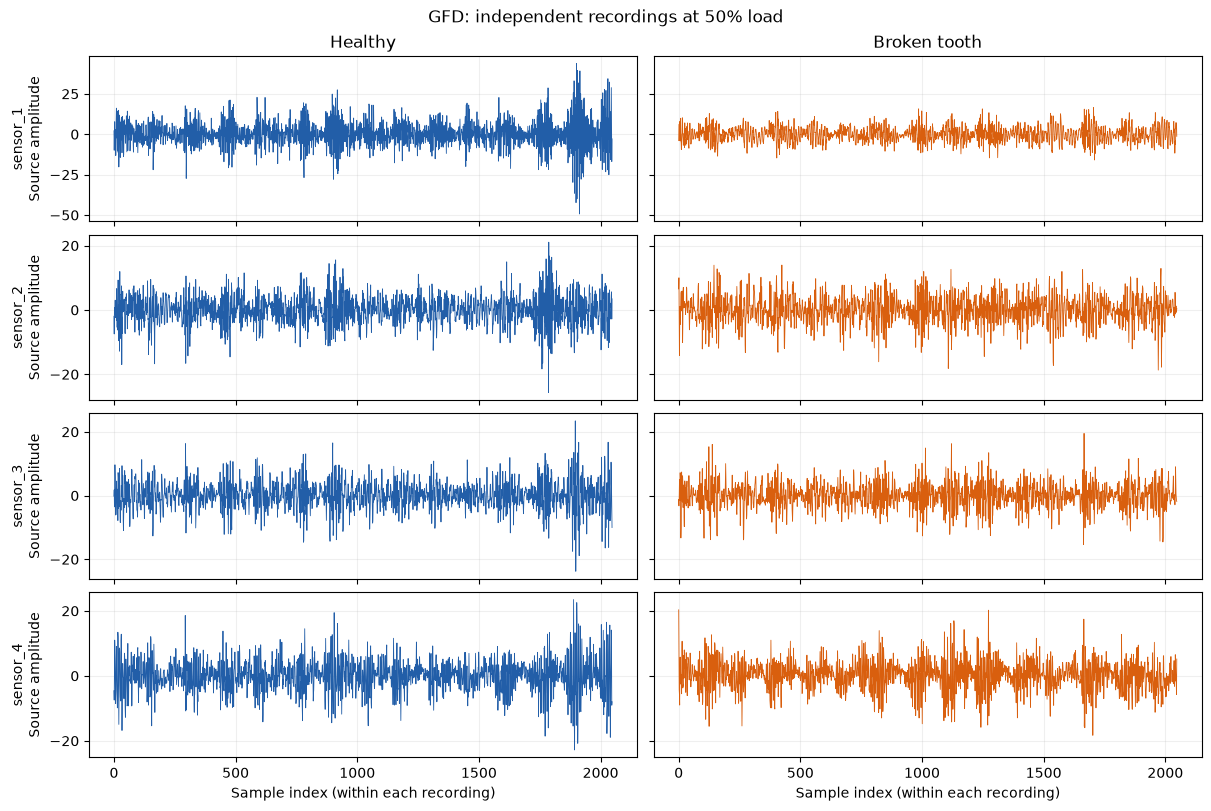

In [3]:
START, STOP = 0, 2048
comparison = plot_waveforms(healthy, broken, start=START, stop=STOP)
# Save one compact, reproducible preview for the dataset README.
assets = ROOT / "pdmdata/datasets/gfd/assets"
assets.mkdir(parents=True, exist_ok=True)
comparison.savefig(assets / "waveforms.png", dpi=100)
plt.show()


## Zoom into the first 256 samples

This shorter view exposes oscillation structure hidden in the longer window.
It is not an annotated machine cycle or a fault-onset interval.


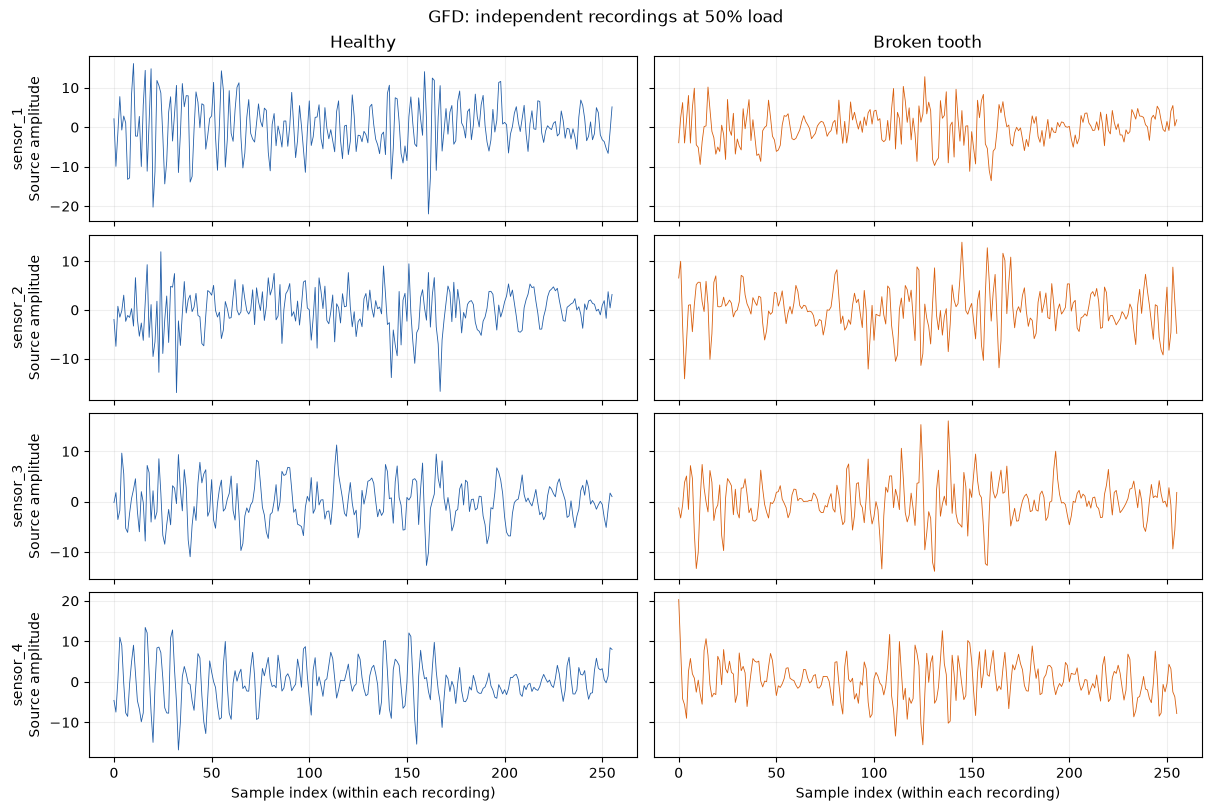

In [4]:
zoom = plot_waveforms(healthy, broken, start=0, stop=256)
plt.show()


## Signal magnitude across all 20 recordings

RMS is calculated over each complete recording, including any nonzero mean.
This is a descriptive comparison across experiments, not a temporal trajectory
or an estimate of uncertainty. A larger RMS alone does not establish a fault.


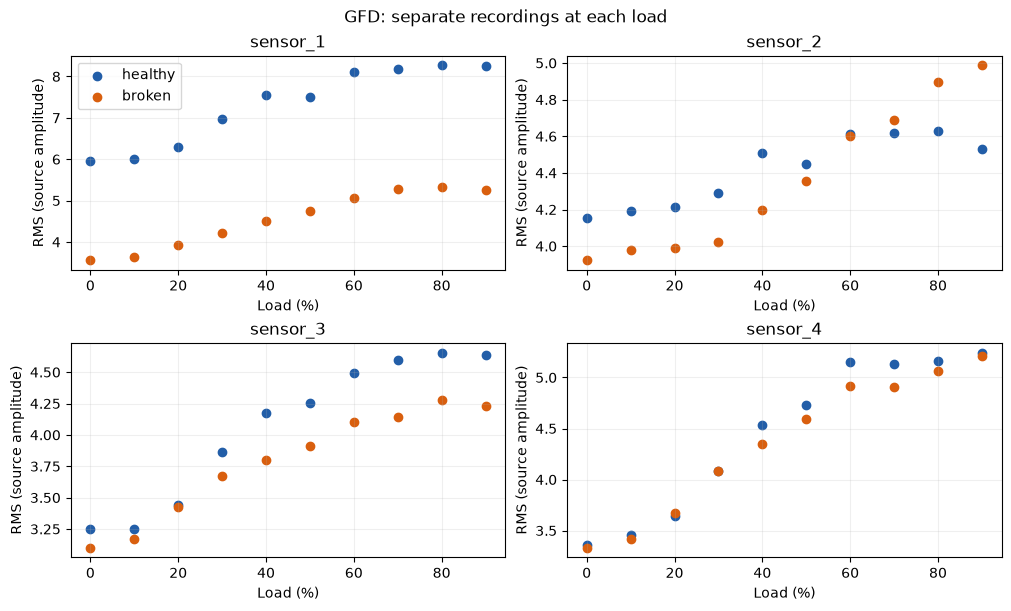

In [5]:
rows = []
for condition in ["healthy", "broken"]:
    for level in range(0, 100, 10):
        frame = pdmdata.load("gfd", condition=condition, load=level)
        for sensor in SENSOR_COLUMNS:
            values = frame[sensor].to_numpy()
            rows.append({"condition": condition, "load": level, "sensor": sensor,
                         "rms": float(np.sqrt(np.mean(values**2))),
                         "mean": float(values.mean()), "std": float(values.std())})
stats = pl.DataFrame(rows)
rms_figure = plot_rms(stats)
plt.show()


## Within-recording sensor relationships

Pearson correlations below use all samples of each selected recording. They
measure marginal linear association, not conditional dependence, causality, or
a Graphical Lasso precision matrix. Condition and load are excluded from inputs.


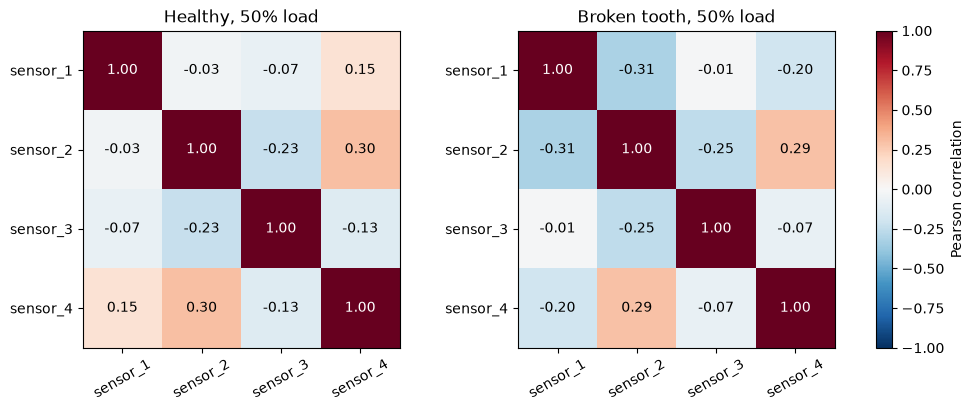

In [6]:
correlation_figure = plot_correlations(healthy, broken)
plt.show()


## Implications for dependency-based segmentation

- Four continuous channels provide a small system for inspecting sensor graphs.
- Use condition and load as recording metadata, keeping them outside sensor inputs.
- Compare multiple windows and loads; these plots do not establish which condition
  has stronger dependencies or whether a multi-scale model performs better.
- There are no supplied within-recording state-transition labels. GFD can support
  comparisons across conditions, but cannot directly validate natural state
  segmentation in the way a continuously labeled sequence can.
- Concatenating files creates synthetic transitions. Report that construction
  explicitly if using it as a controlled benchmark.
- Keep overlapping windows from the same recording out of different evaluation
  splits; the twenty files are not twenty independent machines.
- Establish the acquisition sampling rate from authoritative experiment details
  before translating sample windows into physical time scales or frequency units.
